<a href="https://colab.research.google.com/github/Tamur-Naseem/FLY-RANK/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tamur-Naseem/FLY-RANK/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.
**The Playbook Strategy:**
We translate the Random Forest's continuous probability score (0.0 to 1.0) into discrete actions for the content team.

**Ranked Actions:**
1.  **Priority Refresh:** Model probability > 0.70. These are pages with strong observed signals of decay.
2.  **Monitor & Expand:** Model probability between 0.40 and 0.70. Pages showing mixed signals; monitor for further drops or expand existing sections.
3.  **Stable / No Action:** Model probability < 0.40.

**Reason Codes:**
To give the human reviewer context, we generate reason codes based on the underlying features:
*   `high_impr_decay_risk`: High probability + high impressions (The most urgent).
*   `stale_but_stable`: High age but low probability of decay.
*   `position_slip_risk`: High probability driven by dropping average positions.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data
url = 'https://raw.githubusercontent.com/Tamur-Naseem/FLY-RANK/main/data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(url)

# 2. Setup Features and Train the Model (re-running for the playbook)
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)
features = ['content_age_days', 'impressions_90d', 'sessions_90d', 'avg_position', 'ctr', 'word_count']
X = df[features].fillna(0)
y = df['is_declining']

rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X, y)

# 3. Generate Probabilities
df['rf_prob'] = rf_model.predict_proba(X)[:, 1]

# 4. Assign Actions
conditions = [
    (df['rf_prob'] > 0.70),
    (df['rf_prob'] >= 0.40) & (df['rf_prob'] <= 0.70),
    (df['rf_prob'] < 0.40)
]
choices = ['Priority Refresh', 'Monitor & Expand', 'Stable / No Action']
df['recommended_action'] = np.select(conditions, choices, default='Unknown')

# 5. Assign Reason Codes
df['reason_code'] = 'standard_review'
df.loc[(df['rf_prob'] > 0.70) & (df['impressions_90d'] > 1000), 'reason_code'] = 'high_impr_decay_risk'
df.loc[(df['rf_prob'] > 0.70) & (df['avg_position'] > 10), 'reason_code'] = 'position_slip_risk'
df.loc[(df['rf_prob'] < 0.40) & (df['content_age_days'] > 180), 'reason_code'] = 'stale_but_stable'

# 6. Rank the Queue
ranked_queue = df.sort_values(by=['rf_prob', 'impressions_90d'], ascending=[False, False])

print("--- ACTION PLAYBOOK SUMMARY ---")
print(ranked_queue['recommended_action'].value_counts())


--- ACTION PLAYBOOK SUMMARY ---
recommended_action
Monitor & Expand      20580
Stable / No Action     5081
Priority Refresh       4339
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
**Intended Use:**
This tool is a decision-support system designed to prioritize a content editor's review queue. By bubbling the most at-risk pages to the top, it maximizes the ROI of limited human review time.

**Limits:**
This model relies strictly on historical, observational data. It identifies directional risk, but it does NOT guarantee that a decline is actively happening, nor does it guarantee that rewriting the page will causally recover the traffic. It is also blind to true seasonality (e.g., traffic for "summer tires" dropping in October), which must be accounted for by the human reviewer.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# No code required for this section. The analysis is operational.
print("Operational guidelines defined above.")


Operational guidelines defined above.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*
**The Role of Human Review:**
The model flags the *what*; the human determines the *why*. A reviewer must manually inspect the SERP (Search Engine Results Page) to see if the search intent has fundamentally changed before spending hours rewriting a page.

**The No-Go List (What NOT to automate):**
1.  **Automated Deletion:** Never prune or delete a page automatically based on a low score.
2.  **Automated AI Rewriting:** Never pipe the "Priority Refresh" pages directly into a GenAI tool for automated rewriting without editorial oversight.
3.  **URL Changes:** Do not automatically redirect URLs based on these probability scores.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# No code required for this section. The analysis is operational.
print("No-go constraints defined above.")


No-go constraints defined above.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*
**Monitoring:**
We will monitor `Precision@50` on a monthly basis. We will track how many of the top 50 flagged pages actually required a refresh according to the editorial team's manual review.

**Retrain Triggers:**
1.  **Time-based:** Re-train the model every 6 months to capture shifting baseline metrics.
2.  **Event-based:** Trigger an immediate retraining 30 days after a confirmed major Google Core Algorithm update, as the relative importance of features (like word count vs. CTR) often shifts violently during these rollouts.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# No code required for this section. The analysis is operational.
print("Monitoring triggers defined above.")


Monitoring triggers defined above.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*
Exporting the finalized ranked queue (for the review team) and generating a visual feature importance chart to include in the final research paper next week.

Saved ranked queue to: work/outputs/action_queue.csv
Saved figure to: work/figures/rf_feature_importance.png


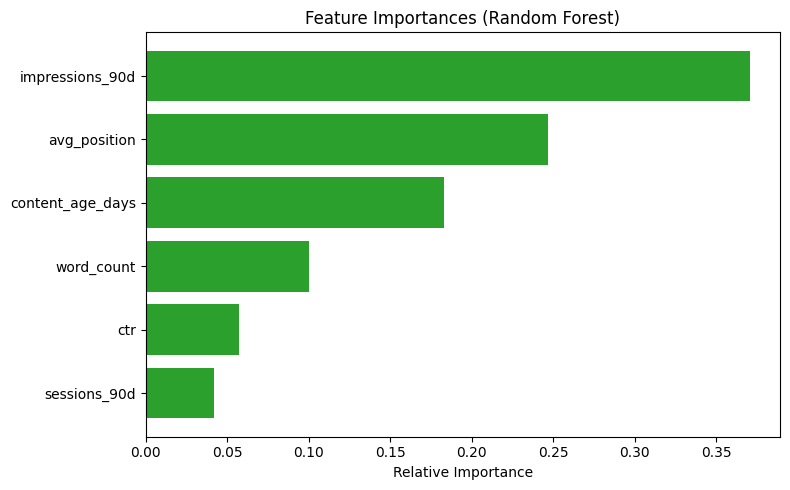

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import matplotlib.pyplot as plt

# Create output directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export the CSV Queue
export_cols = ['content_id', 'client_id', 'recommended_action', 'reason_code', 'rf_prob', 'impressions_90d', 'avg_position']
ranked_queue[export_cols].to_csv('work/outputs/action_queue.csv', index=False)
print("Saved ranked queue to: work/outputs/action_queue.csv")

# Generate and Export the Feature Importance Figure
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='#2ca02c', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()

# Save the figure for the capstone paper
plt.savefig('work/figures/rf_feature_importance.png')
print("Saved figure to: work/figures/rf_feature_importance.png")
plt.show()


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.